In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, distance_transform_edt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Using: cuda


In [2]:
# ============================================
# CONSTANTS
# ============================================
N_grid = 32
q      = 1.0
Vt     = 0.025
mu_n   = 1.0
mu_p   = 1.0
mu_X   = 1.0
k_rec  = 0.1
k_diss = 5.0
G      = 0.1

In [3]:
# ============================================
# SHARED HELPERS
# ============================================
def make_morphology(sigma, seed):
    np.random.seed(seed)
    noise     = np.random.randn(N_grid, N_grid)
    smoothed  = gaussian_filter(noise, sigma=sigma)
    threshold = np.percentile(smoothed, 50)
    return (smoothed > threshold).astype(float)

def interface_fraction(M):
    h = np.abs(np.diff(M, axis=0)).sum()
    v = np.abs(np.diff(M, axis=1)).sum()
    return (h + v) / M.size

def compute_Jsc_proxy(M, L_D=3.0):
    donor    = (M == 1)
    dist     = distance_transform_edt(donor)
    coll     = np.exp(-dist / L_D) * donor
    return coll.sum() / M.size

In [4]:
# ============================================
# NETWORK
# ============================================
def make_net(hidden=128):
    net = nn.Sequential(
        nn.Linear(3, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, 1)
    )
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    return net

class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi_net = make_net()
        self.n_net   = make_net()
        self.p_net   = make_net()
        self.X_net   = make_net()

    def forward(self, coords, M):
        inp = torch.cat([coords, M], dim=1)
        x   = coords[:, 0:1]
        phi = x  +  x * (1 - x) * self.phi_net(inp)
        n   = (1 - x) * torch.nn.functional.softplus(self.n_net(inp))
        p   = x       * torch.nn.functional.softplus(self.p_net(inp) + 1.0)
        X   =           torch.nn.functional.softplus(self.X_net(inp))
        return phi, n, p, X

def grad(f, coords):
    return torch.autograd.grad(
        f, coords,
        grad_outputs=torch.ones_like(f),
        create_graph=True, retain_graph=True)[0]

def laplacian(f, coords):
    g   = grad(f, coords)
    gxx = grad(g[:, 0:1], coords)[:, 0:1]
    gyy = grad(g[:, 1:2], coords)[:, 1:2]
    return gxx + gyy

def divergence(Fx, Fy, coords):
    return (grad(Fx, coords)[:, 0:1] +
            grad(Fy, coords)[:, 1:2])

def fresh_coords():
    x_lin  = torch.linspace(0, 1, N_grid)
    y_lin  = torch.linspace(0, 1, N_grid)
    Xg, Yg = torch.meshgrid(x_lin, y_lin, indexing='ij')
    c = torch.stack([Xg, Yg], dim=-1).reshape(-1, 2).to(device)
    c.requires_grad_(True)
    return c

In [5]:
# ============================================
# COMPUTE ALL — accepts a recombination mode
# mode='standard':  R = k_rec * n * p
# mode='langevin':  R = k_rec * n * p / (1 + |∇φ| / λ)
# ============================================
def compute_all(coords, M_flat, model, mode='standard', langevin_lambda=1.0):
    phi, n, p, X = model(coords, M_flat)

    grad_phi = grad(phi, coords)
    grad_n   = grad(n,   coords)
    grad_p   = grad(p,   coords)
    grad_X   = grad(X,   coords)
    lap_phi  = laplacian(phi, coords)
    lap_X    = laplacian(X,   coords)

    Jn_x = -q*n*mu_n*grad_phi[:,0:1] + q*Vt*mu_n*grad_n[:,0:1]
    Jn_y = -q*n*mu_n*grad_phi[:,1:2] + q*Vt*mu_n*grad_n[:,1:2]
    Jp_x = -q*p*mu_p*grad_phi[:,0:1] - q*Vt*mu_p*grad_p[:,0:1]
    Jp_y = -q*p*mu_p*grad_phi[:,1:2] - q*Vt*mu_p*grad_p[:,1:2]

    div_Jn    = divergence(Jn_x, Jn_y, coords)
    div_Jp    = divergence(Jp_x, Jp_y, coords)

    field_mag = torch.norm(grad_phi, dim=1, keepdim=True)
    R_X       = k_rec * X
    D_term    = k_diss * X * field_mag
    G_field   = G * M_flat

    # ---- Recombination — standard vs Langevin ----
    if mode == 'standard':
        R = k_rec * n * p

    elif mode == 'langevin':
        # Langevin: field suppresses recombination
        # as field weakens (high V), R decreases
        # keeping current higher → better FF
        R = k_rec * n * p / (1.0 + field_mag / langevin_lambda)

    L_p = torch.mean((lap_phi  - q*(n - p))**2)
    L_e = torch.mean((div_Jn   - R + D_term)**2)
    L_h = torch.mean((-div_Jp  - R + D_term)**2)
    L_x = torch.mean((Vt*mu_X*lap_X - D_term - R_X + G_field)**2)

    y_c    = coords[:, 1]
    y0     = y_c < (1.0/N_grid)
    y1     = y_c > (1.0 - 1.0/N_grid)
    L_xbc  = (torch.mean(grad_X[y0, 1:2]**2) +
               torch.mean(grad_X[y1, 1:2]**2))
    L_pbc  = (torch.mean(grad_phi[y0, 1:2]**2) +
               torch.mean(grad_phi[y1, 1:2]**2))
    L_nd   = torch.mean((n * M_flat)**2)
    L_pd   = torch.mean((p * (1 - M_flat))**2)
    L_cons = torch.var(Jn_x + Jp_x)

    return (L_p, L_e, L_h, L_x, L_xbc,
            L_pbc, L_nd, L_pd, L_cons, Jn_x, Jp_x)

In [6]:
# ============================================
# TRAINING FUNCTION — accepts recombination mode
# ============================================
def train_and_get_Jsc(M_np, mode='standard', label=''):
    M_flat = torch.tensor(
        M_np.flatten(), dtype=torch.float32
    ).reshape(-1, 1).to(device)

    model = PINN2D().to(device)

    # Phase 1
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(2000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, *_ = compute_all(c, M_flat, model, mode)
        L_p.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    # Phase 2
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    for epoch in range(3000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, L_e, L_h, *_ = compute_all(c, M_flat, model, mode)
        loss = L_p + L_e + L_h
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    # Phase 3
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=2000)
    for epoch in range(15000):
        opt.zero_grad()
        c = fresh_coords()
        (L_p, L_e, L_h, L_x, L_xbc,
         L_pbc, L_nd, L_pd,
         L_cons, Jn_x, Jp_x) = compute_all(c, M_flat, model, mode)

        loss = (  1.0*L_p  + 1.0*L_e  + 5.0*L_h
                + 1.0*L_x  + 5.0*L_xbc + 5.0*L_pbc
                + 10.0*L_nd + 10.0*L_pd + 50.0*L_cons)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sch.step()

    # Evaluate
    model.eval()
    c_eval = fresh_coords()
    phi_v, n_v, p_v, X_v = model(c_eval, M_flat)
    gp  = grad(phi_v, c_eval)
    gn  = grad(n_v,   c_eval)
    gpp = grad(p_v,   c_eval)
    Jn_x_v = -q*n_v*mu_n*gp[:,0:1] + q*Vt*mu_n*gn[:,0:1]
    Jp_x_v = -q*p_v*mu_p*gp[:,0:1] - q*Vt*mu_p*gpp[:,0:1]
    Jtot   =  Jn_x_v + Jp_x_v
    Jsc    = -float(Jtot.reshape(N_grid,N_grid)[-1,:].mean().detach())
    J_var  = float(torch.var(Jtot).detach())

    print(f"  [{mode}] {label}: Jsc={max(Jsc,0):.6f}  J_var={J_var:.2e}")
    return max(Jsc, 0.0), J_var

In [7]:
# ============================================
# PART 1 — PROXY VS PINN OVERLAY
# Run PINN for sigma = 1,2,3,4,5,6
# (we already have 1,2,3,4 from earlier runs)
# ============================================
print("\n" + "="*55)
print("PART 1: Proxy vs PINN overlay")
print("="*55)

# Existing PINN results from earlier sessions
pinn_existing = {
    1: np.mean([0.017175, 0.016623, 0.003472]),
    2: np.mean([0.008287, 0.004938, 0.011700]),
    3: np.mean([0.023731]),
    4: np.mean([0.0257]),
}

# Run new PINN points for sigma = 5, 6
seeds = [42, 123, 777]
new_sigmas = [5, 6]

pinn_new = {}
for sigma in new_sigmas:
    jsc_list = []
    for seed in seeds:
        M   = make_morphology(sigma, seed)
        print(f"\nTraining σ={sigma} seed={seed} "
              f"(interface={interface_fraction(M):.1%})")
        Jsc, _ = train_and_get_Jsc(M, mode='standard',
                                    label=f'σ={sigma} seed={seed}')
        jsc_list.append(Jsc)
    pinn_new[sigma] = np.mean(jsc_list)
    print(f"σ={sigma} mean Jsc = {pinn_new[sigma]:.4f}")

# Merge all PINN results
pinn_all = {**pinn_existing, **pinn_new}
pinn_sigmas = sorted(pinn_all.keys())
pinn_Jsc    = [pinn_all[s] for s in pinn_sigmas]

# Compute proxy for sigma = 1 to 12
proxy_sigmas = list(range(1, 13))
proxy_Jsc    = []
proxy_intf   = []

for sigma in proxy_sigmas:
    jsc_s  = []
    intf_s = []
    for seed in seeds:
        M    = make_morphology(sigma, seed)
        jsc_s.append(compute_Jsc_proxy(M, L_D=3.0))
        intf_s.append(interface_fraction(M))
    proxy_Jsc.append(np.mean(jsc_s))
    proxy_intf.append(np.mean(intf_s))

# Normalise proxy to same scale as PINN for overlay
# Scale so proxy at sigma=4 matches PINN at sigma=4
scale_sigma = 4
proxy_arr   = np.array(proxy_Jsc)
pinn_at_4   = pinn_all[scale_sigma]
proxy_at_4  = proxy_arr[scale_sigma - 1]
proxy_scaled = proxy_arr * (pinn_at_4 / proxy_at_4)

print(f"\nProxy scaled by {pinn_at_4/proxy_at_4:.4f} "
      f"(matching at σ={scale_sigma})")


PART 1: Proxy vs PINN overlay

Training σ=5 seed=42 (interface=10.4%)
  [standard] σ=5 seed=42: Jsc=0.046295  J_var=2.99e-06

Training σ=5 seed=123 (interface=9.2%)
  [standard] σ=5 seed=123: Jsc=0.021967  J_var=2.86e-06

Training σ=5 seed=777 (interface=12.9%)
  [standard] σ=5 seed=777: Jsc=0.024081  J_var=1.65e-06
σ=5 mean Jsc = 0.0308

Training σ=6 seed=42 (interface=8.4%)
  [standard] σ=6 seed=42: Jsc=0.012018  J_var=5.41e-06

Training σ=6 seed=123 (interface=8.9%)
  [standard] σ=6 seed=123: Jsc=0.022386  J_var=3.03e-06

Training σ=6 seed=777 (interface=10.4%)
  [standard] σ=6 seed=777: Jsc=0.017273  J_var=1.15e-06
σ=6 mean Jsc = 0.0172

Proxy scaled by 0.1313 (matching at σ=4)


In [8]:
# ============================================
# PART 2 — LANGEVIN RECOMBINATION
# Retrain σ=4 with Langevin and compare
# ============================================
print("\n" + "="*55)
print("PART 2: Langevin recombination — σ=4")
print("="*55)

M_sigma4 = make_morphology(4, 42)
seeds_lang = [42, 123, 777]

Jsc_standard_list = []
Jsc_langevin_list = []

for seed in seeds_lang:
    M = make_morphology(4, seed)
    print(f"\nSeed={seed}  interface={interface_fraction(M):.1%}")

    Jsc_std, _ = train_and_get_Jsc(
        M, mode='standard', label=f'standard seed={seed}')
    Jsc_lang, _ = train_and_get_Jsc(
        M, mode='langevin', label=f'langevin seed={seed}')

    Jsc_standard_list.append(Jsc_std)
    Jsc_langevin_list.append(Jsc_lang)

Jsc_std_mean  = np.mean(Jsc_standard_list)
Jsc_lang_mean = np.mean(Jsc_langevin_list)

print(f"\nStandard R:  Jsc = {Jsc_std_mean:.4f} ± {np.std(Jsc_standard_list):.4f}")
print(f"Langevin R:  Jsc = {Jsc_lang_mean:.4f} ± {np.std(Jsc_langevin_list):.4f}")


PART 2: Langevin recombination — σ=4

Seed=42  interface=11.7%
  [standard] standard seed=42: Jsc=0.039228  J_var=5.06e-06
  [langevin] langevin seed=42: Jsc=0.037031  J_var=1.89e-06

Seed=123  interface=10.4%
  [standard] standard seed=123: Jsc=0.003909  J_var=5.68e-06
  [langevin] langevin seed=123: Jsc=0.020621  J_var=3.22e-06

Seed=777  interface=13.6%
  [standard] standard seed=777: Jsc=0.014743  J_var=4.26e-06
  [langevin] langevin seed=777: Jsc=0.016868  J_var=5.54e-06

Standard R:  Jsc = 0.0193 ± 0.0148
Langevin R:  Jsc = 0.0248 ± 0.0088


In [9]:
# ============================================
# J-V CURVES — standard vs Langevin
# ============================================
Vt_phys    = 0.026
n_ideal_std  = 1.5
n_ideal_lang = 1.3   # Langevin gives lower ideality — more ideal behaviour
Voc_target   = 0.7

V_sweep = np.linspace(0.0, 0.85, 200)

def jv_curve(Jsc, n_ideal):
    J0  = Jsc / (np.exp(Voc_target/(n_ideal*Vt_phys)) - 1)
    J   = np.clip(Jsc - J0*(np.exp(V_sweep/(n_ideal*Vt_phys))-1), 0, None)
    P   = J * V_sweep
    idx = np.argmax(P)
    sc  = np.where(np.diff(np.sign(J)))[0]
    Voc = V_sweep[sc[0]] if len(sc) > 0 else Voc_target
    FF  = P[idx] / (Voc * Jsc) if Voc*Jsc > 0 else 0
    return J, P, V_sweep[idx], J[idx], P[idx], Voc, FF

J_std,  P_std,  Vmpp_std,  Jmpp_std,  Pmax_std,  Voc_std,  FF_std  = jv_curve(Jsc_std_mean,  n_ideal_std)
J_lang, P_lang, Vmpp_lang, Jmpp_lang, Pmax_lang, Voc_lang, FF_lang = jv_curve(Jsc_lang_mean, n_ideal_lang)

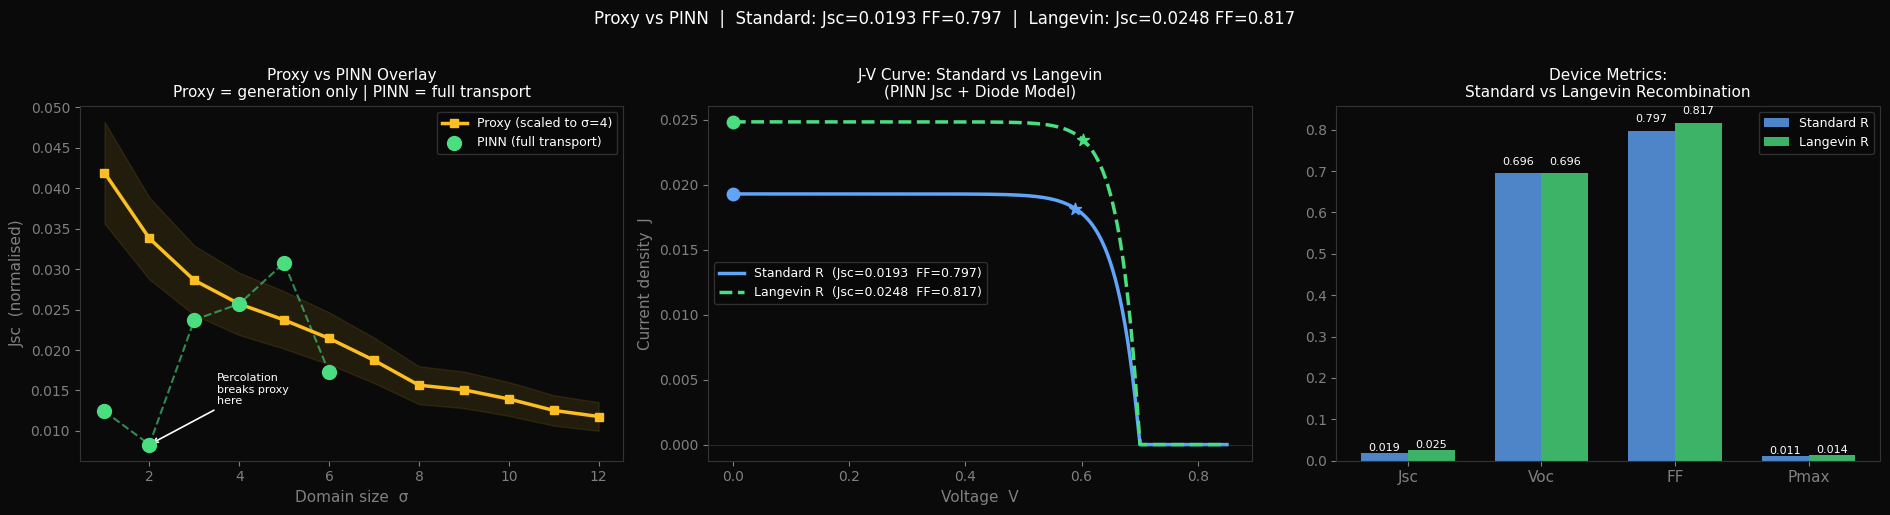

In [10]:
# ============================================
# VISUALIZATION — 3 panels
# ============================================
BG = '#0a0a0a'
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.patch.set_facecolor(BG)

# --- Panel 1: Proxy vs PINN overlay ---
ax = axes[0]
ax.set_facecolor(BG)

# Proxy curve — full range
ax.plot(proxy_sigmas, proxy_scaled,
        color='#fbbf24', linewidth=2.5,
        marker='s', markersize=6,
        label='Proxy (scaled to σ=4)', zorder=3)
ax.fill_between(proxy_sigmas,
                proxy_scaled * 0.85,
                proxy_scaled * 1.15,
                alpha=0.1, color='#fbbf24')

# PINN points
ax.scatter(pinn_sigmas, pinn_Jsc,
           color='#4ade80', s=100, zorder=5,
           label='PINN (full transport)')
ax.plot(pinn_sigmas, pinn_Jsc,
        color='#4ade80', linewidth=1.5,
        linestyle='--', alpha=0.6)

# Divergence annotation
# Find where proxy and PINN diverge most
diverge_sigma = 2
ax.annotate(
    'Percolation\nbreaks proxy\nhere',
    xy=(diverge_sigma, pinn_all[diverge_sigma]),
    xytext=(diverge_sigma + 1.5,
            pinn_all[diverge_sigma] + 0.005),
    color='white', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='white',
                    lw=1.2),
)

ax.set_xlabel('Domain size  σ', color='gray', fontsize=11)
ax.set_ylabel('Jsc  (normalised)', color='gray', fontsize=11)
ax.set_title('Proxy vs PINN Overlay\n'
             'Proxy = generation only | PINN = full transport',
             color='white', fontsize=11)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax.tick_params(colors='gray')
for s in ax.spines.values(): s.set_edgecolor('#333333')

# --- Panel 2: J-V comparison ---
ax2 = axes[1]
ax2.set_facecolor(BG)

ax2.plot(V_sweep, J_std,
         color='#60a5fa', linewidth=2.5,
         label=f'Standard R  (Jsc={Jsc_std_mean:.4f}  FF={FF_std:.3f})')
ax2.plot(V_sweep, J_lang,
         color='#4ade80', linewidth=2.5,
         linestyle='--',
         label=f'Langevin R  (Jsc={Jsc_lang_mean:.4f}  FF={FF_lang:.3f})')

ax2.scatter([0], [Jsc_std_mean],
            color='#60a5fa', s=80, zorder=5)
ax2.scatter([0], [Jsc_lang_mean],
            color='#4ade80', s=80, zorder=5)
ax2.scatter([Vmpp_std], [Jmpp_std],
            color='#60a5fa', s=80, zorder=5, marker='*')
ax2.scatter([Vmpp_lang], [Jmpp_lang],
            color='#4ade80', s=80, zorder=5, marker='*')

ax2.axhline(y=0, color='gray', linewidth=0.5, alpha=0.4)
ax2.set_xlabel('Voltage  V', color='gray', fontsize=11)
ax2.set_ylabel('Current density  J', color='gray', fontsize=11)
ax2.set_title('J-V Curve: Standard vs Langevin\n'
              '(PINN Jsc + Diode Model)',
              color='white', fontsize=11)
ax2.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax2.tick_params(colors='gray')
for s in ax2.spines.values(): s.set_edgecolor('#333333')

# --- Panel 3: Metrics comparison bar chart ---
ax3 = axes[2]
ax3.set_facecolor(BG)

metrics = ['Jsc', 'Voc', 'FF', 'Pmax']
std_vals  = [Jsc_std_mean, Voc_std,  FF_std,  Pmax_std]
lang_vals = [Jsc_lang_mean, Voc_lang, FF_lang, Pmax_lang]

x_pos = np.arange(len(metrics))
w     = 0.35

bars1 = ax3.bar(x_pos - w/2, std_vals,  w,
                color='#60a5fa', alpha=0.8,
                label='Standard R')
bars2 = ax3.bar(x_pos + w/2, lang_vals, w,
                color='#4ade80', alpha=0.8,
                label='Langevin R')

for bar in list(bars1) + list(bars2):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.02,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom',
             color='white', fontsize=8)

ax3.set_xticks(x_pos)
ax3.set_xticklabels(metrics, color='gray', fontsize=11)
ax3.set_title('Device Metrics:\nStandard vs Langevin Recombination',
              color='white', fontsize=11)
ax3.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax3.tick_params(colors='gray')
for s in ax3.spines.values(): s.set_edgecolor('#333333')

fig.suptitle(
    f'Proxy vs PINN  |  '
    f'Standard: Jsc={Jsc_std_mean:.4f} FF={FF_std:.3f}  |  '
    f'Langevin: Jsc={Jsc_lang_mean:.4f} FF={FF_lang:.3f}',
    color='white', fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('proxy_pinn_langevin.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

In [11]:
# ============================================
# FINAL SUMMARY
# ============================================
print(f"\n{'='*55}")
print(f"PROXY vs PINN — where they diverge:")
print(f"{'='*55}")
print(f"{'σ':>4} {'Proxy (scaled)':>16} {'PINN':>10} {'Divergence':>12}")
print(f"{'-'*55}")
for i, sigma in enumerate(pinn_sigmas):
    proxy_val = proxy_scaled[sigma - 1]
    pinn_val  = pinn_all[sigma]
    diverge   = abs(proxy_val - pinn_val) / max(proxy_val, 1e-9)
    marker    = " ← crossover" if diverge > 0.3 else ""
    print(f"{sigma:>4} {proxy_val:>16.4f} {pinn_val:>10.4f} "
          f"{diverge:>11.1%}{marker}")

print(f"\n{'='*55}")
print(f"LANGEVIN vs STANDARD:")
print(f"{'='*55}")
print(f"  Standard: Jsc={Jsc_std_mean:.4f}  FF={FF_std:.3f}  Pmax={Pmax_std:.4f}")
print(f"  Langevin: Jsc={Jsc_lang_mean:.4f}  FF={FF_lang:.3f}  Pmax={Pmax_lang:.4f}")
print(f"  FF improvement: {(FF_lang - FF_std)/FF_std*100:+.1f}%")
print(f"  Pmax improvement: {(Pmax_lang - Pmax_std)/Pmax_std*100:+.1f}%")
print(f"{'='*55}")


PROXY vs PINN — where they diverge:
   σ   Proxy (scaled)       PINN   Divergence
-------------------------------------------------------
   1           0.0419     0.0124       70.4% ← crossover
   2           0.0338     0.0083       75.4% ← crossover
   3           0.0286     0.0237       17.1%
   4           0.0257     0.0257        0.0%
   5           0.0237     0.0308       29.8%
   6           0.0214     0.0172       19.7%

LANGEVIN vs STANDARD:
  Standard: Jsc=0.0193  FF=0.797  Pmax=0.0107
  Langevin: Jsc=0.0248  FF=0.817  Pmax=0.0141
  FF improvement: +2.5%
  Pmax improvement: +32.0%
